# Assignment 5: Link Analysis

** IMPORTANT NOTE ** Due to a problem with the citations file (which would take too much time for me to re-generate before the start of the assignment), we use a dataset from previous year for this assignment. Please upload the four 'emotion' files from Canvas in your data folder.

In this assignment, we will use network-based algorithms, such as PageRank, to improve our search results. After the last assignment on evaluating IR systems, we go back to our PubMed dataset of scientific papers. In this dataset, we look at two graphs in particular: the co-authorship network and the citation network.

The citation network is similar to the link network of the web: Citations are like web links pointing to other documents. We can therefore apply the same network-based ranking methods.

## Code from previous assignments

In [1]:
import sys, os, zipfile
print("Python version:", sys.version)


import pickle, bz2
from collections import defaultdict, namedtuple, Counter
from math import log10, sqrt
from IPython.display import display, HTML
import matplotlib.pyplot as plt

# show plots inline within the notebook
%matplotlib inline
# set plots' resolution
plt.rcParams['savefig.dpi'] = 100

Python version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [2]:
Ids_file = 'data/emotion_Ids.pkl.bz2'



        
        
Summaries_file = 'data/emotion_Summaries.pkl.bz2'
Citations_file = 'data/emotion_Citations.pkl.bz2'
Abstracts_file = 'data/emotion_Abstracts.pkl.bz2'

Ids = pickle.load( bz2.BZ2File( Ids_file, 'rb' ) )
Summaries = pickle.load( bz2.BZ2File( Summaries_file, 'rb' ) )
Citations = pickle.load( bz2.BZ2File( Citations_file, 'rb' ) )
Abstracts = pickle.load( bz2.BZ2File( Abstracts_file, 'rb' ) )

paper = namedtuple( 'paper', ['title', 'authors', 'year', 'doi'] )

for (id, paper_info) in Summaries.items():
    Summaries[id] = paper( *paper_info )
    
Ids[:5]
    

[34649191, 34649067, 34648542, 34648235, 34648188]

In [3]:
def display_summary( id, show_abstract=False, show_id=True, extra_text='' ):
    """
    Function for printing a paper's summary through IPython's Rich Display System.
    Trims long author lists, and adds a link to the paper's DOI (when available).
    """
    s = Summaries[id]
    lines = []
    title = s.title
    if s.doi != '':
        title = '<a href=http://dx.doi.org/{:s}>{:s}</a>'.format(s.doi, title)
    title = '<strong>' + title + '</strong>'
    lines.append(title)
    authors = ', '.join( s.authors[:20] ) + ('' if len(s.authors) <= 20 else ', ...')
    lines.append(str(s.year) + '. ' + authors)
    if (show_abstract):
        lines.append('<small><strong>Abstract:</strong> <em>{:s}</em></small>'.format(Abstracts[id]))
    if (show_id):
        lines.append('[ID: {:d}]'.format(id))
    if (extra_text != ''):
         lines.append(extra_text)
    display( HTML('<br>'.join(lines)) )

In [4]:
def tokenize(text):
    return text.split(' ')

def preprocess(tokens):
    result = []
    for token in tokens:
        result.append(token.lower())
    return result

In [5]:
inverted_index = defaultdict(list)

for id in sorted(Summaries.keys()):
    term_set = set(preprocess(tokenize(Summaries[id].title)))
    if id in Abstracts:
        term_set.update(preprocess(tokenize(Abstracts[id])))
    for term in term_set:
        inverted_index[term].append(id)

tf_matrix = defaultdict(Counter)

for doc_id in Summaries.keys():
    tokens = preprocess(tokenize(Summaries[doc_id].title))
    if (doc_id in Abstracts):
        tokens.extend(preprocess(tokenize(Abstracts[doc_id])))
    tf_matrix[doc_id] = Counter(tokens)

def tf(t,d):
    return float(tf_matrix[d][t])

def df(t):
    return float(len(inverted_index[t]))

num_documents = float(len(Summaries))

def idf(t):
    return log10((num_documents + 1)/(df(t) + 1))

def tfidf(t,d):
    return tf(t,d) * idf(t)

## Co-authorship network

We start by building a mapping from authors to the set of identifiers of papers they authored.  We'll be using Python sets again for that purpose.

In [6]:
papers_of_author = defaultdict(set)

for (id, p) in Summaries.items():
    for a in p.authors:
        papers_of_author[a].add(id)
        #print(a)

Let's try it out:

In [7]:
papers_of_author['Eriksen HR']

{9309949, 17760288, 31649584}

In [8]:
for id in papers_of_author['Eriksen HR']:
    display_summary(id)

We can now build a co-authorship network, that is a graph linking authors to the set of co-authors they have published with:

In [9]:
coauthors = defaultdict(set)

for p in Summaries.values():
    for a in p.authors:
        coauthors[a].update(p.authors)

# The code above results in each author being listed as having co-authored with himself/herself.
# We remove these self-references here:
for (a, ca) in coauthors.items():
    ca.remove(a)

And let's try it out again:

In [10]:
print(', '.join( coauthors['Eriksen HR'] ))

Grant I, Marquis P, Palinkas LA, Dittrich WH, Jakobsen H, Olff M, Johansen T, Lyby PS, Suedfeld P, Jensen C, Holsen IN, Svensen E, Øyeflaten I, Ursin H, Orre IJ


Unlike a citation or link network, the edges of this co-authorship network are not directed: There is no direction (no arrow) in the link between author 'Eriksen HR' and 'Suedfeld P', for example. With our chosen implementation, each of these links in fact appears twice in our data, as we also get 'Eriksen HR' as co-author when we look for 'Suedfeld P':

In [11]:
print(', '.join( coauthors['Suedfeld P'] ))

Marquis P, Palinkas LA, Svensen E, Grant I, Eriksen HR, Ursin H, Orre IJ


With that in mind, we can calculate some basic statistics about our graph:

In [12]:
print('Number of nodes (authors): ', len(coauthors))

# We divide by two here to account for the fact that each edge is represented twice (see above):
coauthor_rel_count = int(sum( len(c) for c in coauthors.values() ) / 2)
print('Number of links (co-authorship relations): ', coauthor_rel_count)

Number of nodes (authors):  99675
Number of links (co-authorship relations):  590848


With this data at hand, we can plot the [degree distribution](https://en.wikipedia.org/wiki/Degree_distribution) by showing the number of collaborators a scientist has published with:

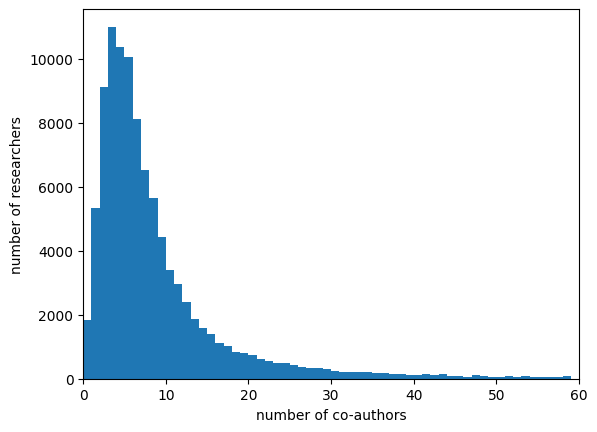

In [13]:
plt.hist( x=[ len(ca) for ca in coauthors.values() ], bins=range(60) )
plt.xlabel('number of co-authors')
plt.ylabel('number of researchers')
plt.xlim(0,60);

Now that we have explored this network, let's move to the citation network.

## Citations network

Next, we can look at the citation network. In contrast to the co-authorship network, the citation network is a _directed_ network, where edges can be drawn as arrows. We'll start by expanding the our data about citations into two mappings: 

* `papers_citing[id]`: papers citing a given paper
* `cited_by[id]`: papers cited by a given paper (in other words: its list of references)

`papers_citing` will give us the list of a node's incoming links, whereas `cited_by` will give us the list of its outgoing links.

In [14]:
papers_citing = Citations  # no changes needed, this is what we are storing already in the Citations dataset

cited_by = defaultdict(list)

for ref, papers_citing_ref in papers_citing.items():
    for id in papers_citing_ref:
        cited_by[ id ].append( ref )
        
print(len(cited_by))
print(len(papers_citing))

190289
46483


As we are dealing with a subset of the data (the papers mentioning "emotion"), `papers_citing` can contain references to papers outside of our subset. On the other hand, the way we created `cited_by`, it will only contain backward references from within our dataset, meaning that it is incomplete with respect to the whole dataset. Nethertheless, we can use this citation network on our subset of pandemic-related papers to implement link analysis techniques.

Let us now look at an exemplary paper, let's say the one with identifier 26784347. We can now use the `cited_by` mapping to retrieve its (incomplete) list of references:

In [15]:
paper_id = 26784347
refs = { id : Summaries[id].title for id in cited_by[paper_id] }
print(len(refs), 'references found for paper', paper_id)
refs

 

39 references found for paper 26784347


{24708508: 'Judgments of subtle facial expressions of emotion.',
 24388852: 'Dynamic facial expressions of emotion transmit an evolving hierarchy of signals over time.',
 23659578: 'Classification of dynamic facial expressions of emotion presented briefly.',
 22876223: 'Attention and awareness each influence amygdala activity for dynamic bodily expressions-a short review.',
 22131445: 'The resolution of facial expressions of emotion.',
 22081890: 'Introducing the Geneva Multimodal expression corpus for experimental research on emotion perception.',
 21859206: 'Moving faces, looking places: validation of the Amsterdam Dynamic Facial Expression Set (ADFES).',
 20809200: 'Facial emotion recognition in autism spectrum disorders: a review of behavioral and neuroimaging studies.',
 19884144: 'The face is not an empty canvas: how facial expressions interact with facial appearance.',
 19803591: 'Emotion recognition from expressions in face, voice, and body: the Multimodal Emotion Recognition T

If we lookup the same paper in `papers_citing`, we now see that some of the cited papers are themselves in our dataset, but others are not (shown below as `'??'`):

In [16]:
#print(papers_citing[paper_id])

{ id : Summaries.get(id,['??'])[0]  for id in papers_citing[paper_id] }


{34138924: '??',
 33958630: 'The paradoxical role of emotional intensity in the perception of vocal affect.',
 33930026: 'SUST Bangla Emotional Speech Corpus (SUBESCO): An audio-only emotional speech corpus for Bangla.',
 33053797: 'Recognizing Emotions through Facial Expressions: A Largescale Experimental Study.',
 32804342: 'Human and machine validation of 14 databases of dynamic facial expressions.',
 32170180: 'Perception of Discrete Emotions in Others: Evidence for Distinct Facial Mimicry Patterns.',
 31762947: 'Are you angry at me? Negative interpretations of neutral facial expressions are linked to child maltreatment but not to posttraumatic stress disorder.',
 31258497: 'Development and Validation of Verbal Emotion Vignettes in Portuguese, English, and German.',
 30800085: '??',
 29928240: "Incongruence Between Observers' and Observed Facial Muscle Activation Reduces Recognition of Emotional Facial Expressions From Video Stimuli.",
 29370198: 'Gender differences in emotion perc

Paper 34138924, for example, is not in our dataset and we do not have any direct information about it, but its repeated occurrence in other papers' citation lists does allow us to reconstruct some of its references. Below is the list of papers in our dataset cited by that paper:

In [17]:
paper_id2 = 34138924
refs2 = { id : Summaries[id].title for id in cited_by[paper_id2] }
print(len(refs2), 'references identified for the paper with id', paper_id2)
refs2

20 references identified for the paper with id 34138924


{32804342: 'Human and machine validation of 14 databases of dynamic facial expressions.',
 31834900: 'The effect of emotional information from eyes on empathy for pain: A subliminal ERP study.',
 31622426: 'Assessing the convergent validity between the automated emotion recognition software Noldus FaceReader 7 and Facial Action Coding System Scoring.',
 30744534: "Validating the Radboud faces database from a child's perspective.",
 30589868: "Subjective ratings and emotional recognition of children's facial expressions from the CAFE set.",
 30273355: 'Cross-cultural emotion recognition and evaluation of Radboud faces database with an Indian sample.',
 29218587: 'Facial expression analysis with AFFDEX and FACET: A validation study.',
 28553255: 'Development of the Korean Facial Emotion Stimuli: Korea University Facial Expression Collection 2nd Edition.',
 26784347: 'Validation of the Amsterdam Dynamic Facial Expression Set--Bath Intensity Variations (ADFES-BIV): A Set of Videos Expressi

Now that we have a better understanding about the data we're dealing with, let us obtain again some basic statistics about our graph.

In [18]:
n = len(Ids)
print('Number of papers in our subset: {:d} ({:.2f} %)'.format(n, 100.0) )

with_citation = [ id for id in Ids if papers_citing[id] != [] ]
with_citation_rel = 100. * len(with_citation) / n
print('Number of papers cited at least once: {:d} ({:.2f} %)'.format(len(with_citation), with_citation_rel) )

isolated = set( id for id in Ids if papers_citing[id] == [] and id not in cited_by )
isolated_rel = 100. * len(isolated) / n
print('Number of isolated nodes:  {:d} ({:.2f} %)'.format(len(isolated), isolated_rel) )

Number of papers in our subset: 46483 (100.00 %)
Number of papers cited at least once: 35018 (75.34 %)
Number of isolated nodes:  8737 (18.80 %)


In [19]:
id_set = set( Ids )
citing_set = set( cited_by.keys() )

outsiders = citing_set - id_set   # set difference
nodes = citing_set | id_set   # set union
non_isolated = nodes - isolated   # set difference

print('Overall number of nodes: {:d} ({:.2f} %)'.format(len(nodes), 100.0) )

non_isolated_rel = 100. * len(non_isolated) / len(nodes)
print('Number of non-isolated nodes: {:d} ({:.2f} %)'.format(len(non_isolated), non_isolated_rel) )

outsiders_rel = 100. * len(outsiders) / len(nodes)
print('Number of nodes outside our subset: {:d} ({:.2f} %)'.format( len(outsiders), outsiders_rel ) )

Overall number of nodes: 221889 (100.00 %)
Number of non-isolated nodes: 213152 (96.06 %)
Number of nodes outside our subset: 175406 (79.05 %)


In [20]:
all_citations = [ c for citing in papers_citing.values() for c in citing ]
outsider_citations = [ c for citing in papers_citing.values() for c in citing if c in outsiders ]

print('Overall number of links (citations): {:d} ({:.2f} %)'.format(len(all_citations), 100.0) )

outsider_citations_rel = 100. * len(outsider_citations) / len(all_citations)
print('Citations outside the subset: {:d} ({:.2f} %)'.format(len(outsider_citations), outsider_citations_rel) )

Overall number of links (citations): 562891 (100.00 %)
Citations outside the subset: 401831 (71.39 %)


Let us now find our which 10 papers are the most cited in our dataset.

In [21]:
citation_count_per_paper = [ (id, len(citations)) for (id,citations) in papers_citing.items() ]
sorted_by_citation_count = sorted(citation_count_per_paper, key=lambda i:i[1], reverse=True)

for (id, c) in sorted_by_citation_count[:10]:
    display_summary(id, extra_text = 'Citation count: ' + str(c))

Before we can start calculating some interesting network metrics, we will first have a closer look at the Python package that we are going to use for that.

## Link Analysis for Search Engines

In order to use the citation network, we need to be able to perform some complex graph algorithms on it. To make our lives easier, we will use [NetworkX](https://pypi.python.org/pypi/networkx), a Python package for dealing with complex networks:

In [22]:
! pip install --user networkx


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [23]:
import networkx as nx

G = nx.DiGraph(cited_by)

We now have a NetworkX Directed Graph stored in `G`, where a node represents a paper, and an edge represents a citation. This means we can now apply the [algorithms](https://networkx.org/documentation/stable/reference/algorithms/index.html) and [functions](https://networkx.org/documentation/stable/reference/functions.html) of NetworkX to our graph:

In [24]:
#print(nx.info(G)) //outdated function
print('Number of nodes:', G.number_of_nodes())
print('Number of edges:', G.number_of_edges())
print('Directed graph:', nx.is_directed(G))
print('Density of graph:', nx.density(G))

Number of nodes: 213152
Number of edges: 562891
Directed graph: True
Density of graph: 1.2389321369843012e-05


As this graph was generated from citations only, we need to add all isolated nodes (nodes that are not cited and do not cite other papers) as well:

In [25]:
G.add_nodes_from(isolated)

And now we get slightly different values:

In [26]:
#print(nx.info(G)) //outdated function
print('Number of nodes:', G.number_of_nodes())
print('Number of edges:', G.number_of_edges())
print('Directed graph:', nx.is_directed(G))
print('Density of graph:', nx.density(G))

Number of nodes: 221889
Number of edges: 562891
Directed graph: True
Density of graph: 1.1432855547712948e-05


Now we are ready to use this package for our tasks.

----------

# Tasks

**Your name:** Zayne Melendez

### Task 1

Plot the in-degree distribution (that is, the distribution of the number of incoming links; see [here](https://en.wikipedia.org/wiki/Degree_distribution) and [here](http://mathinsight.org/degree_distribution) for more detailed explanations) for the citation network. What can you tell about the shape of this distribution, and what does this tell us about the network?

{0: (186871, 0.84218235243748), 1: (5559, 0.02505306707407758), 2: (3974, 0.017909855828815307), 8: (1210, 0.005453177038969936), 4: (2430, 0.010951421656774334), 3: (2991, 0.013479712829387668), 21: (310, 0.0013970949438683305), 18: (400, 0.001802703153378491), 5: (2132, 0.009608407807507357), 6: (1717, 0.007738103285877173), 7: (1414, 0.006372555647192966), 22: (270, 0.0012168246285304814), 10: (915, 0.004123683463353298), 11: (877, 0.003952426663782342), 12: (691, 0.0031141696974613434), 14: (647, 0.002915872350589709), 9: (1042, 0.004696041714550969), 15: (511, 0.0023029532784410224), 16: (503, 0.0022668992153734523), 84: (21, 9.464191555237078e-05), 33: (142, 0.0006399596194493644), 42: (97, 0.0004371555146942841), 57: (48, 0.00021632437840541892), 41: (75, 0.0003380068412584671), 20: (303, 0.001365547638684207), 26: (192, 0.0008652975136216757), 13: (626, 0.0028212304350373383), 19: (380, 0.0017125679957095666), 23: (240, 0.0010816218920270946), 67: (32, 0.00014421625227027928), 

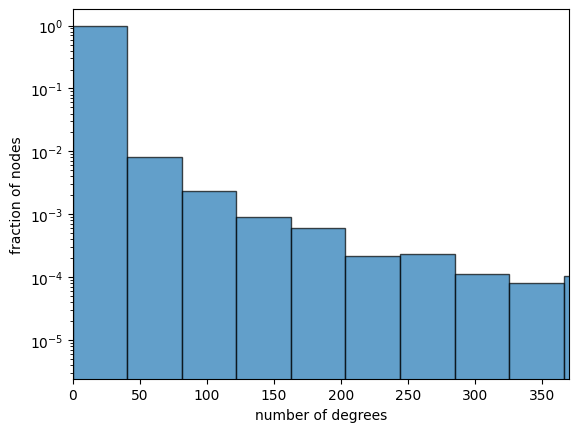

In [27]:
degreeCount = {}
for Node in G.nodes():
   if G.in_degree(Node) not in degreeCount:
      degreeCount[G.in_degree(Node)] = 1
   else:
      degreeCount[G.in_degree(Node)] += 1

for degree in sorted(degreeCount.keys()):
   degreeCount[degree] = (degreeCount[degree], degreeCount[degree]/G.number_of_nodes())


nodes = []
values = []
for i in degreeCount:
   nodes.append(i)
   values.append(degreeCount[i][1])


plt.hist(nodes, weights=values, bins=50, edgecolor='black', alpha=0.7, log=True,)
plt.xlabel('number of degrees')
plt.ylabel('fraction of nodes')
plt.xlim(0,len(degreeCount));

print(degreeCount)


**Answer:** 
The in-degree distribution is very disproportionate, from the graph and data you can see that most papers receive few or no citations while only a small number get many citations. This indicates a scale-free network structure where a few influential papers act as major hubs, suggesting preferential treatment where papers that are already well-cited are more likely to be cited again.

### Task 2

Using the [Link Analysis](https://networkx.org/documentation/stable/reference/algorithms/link_analysis.html) algorithms provided by NetworkX, calculate the PageRank score for all nodes in the citation network, and store the result in a variable called `pageranks`.

To test this, create first a list of all papers that are cited by exactly 10 other papers (using `papers_citing` defined above). Then sort these papers by their PageRank and retrieve the paper IDs with the maximum and minimum PageRank values. Print these minimum and maximum PageRank values together with their paper IDs.

To print PageRank values, you might want to use commands like `print('{:.6f}'.format(var))` to use regular decimal notation with a fixed number of decimal places.

In [ ]:
papersCitedByTen = []
for id in papers_citing.keys():
        if len(papers_citing[id]) == 10:
            papersCitedByTen.append(id)

idRanks = []
pageranks = nx.pagerank(G)
for id in papersCitedByTen:
    idRanks.append( (id, pageranks[id]) )
idRanks.sort( key=lambda x: x[1], reverse=True )
print('Ranking list:', idRanks)

maxRanked = idRanks[0]
minRanked = idRanks[-1]

print('\nHighest Ranked ID:', maxRanked[0], '- Score: {:.6f}'.format(maxRanked[1]))
print('Lowest Ranked ID:', minRanked[0], '- Score: {:.6f}'.format(minRanked[1]))


Ranking list: [(12382205, 3.798155474440496e-05), (19619974, 3.785512107504302e-05), (16393025, 3.234942075403847e-05), (17620404, 3.0619757343737486e-05), (21392417, 2.9522047833179264e-05), (7984168, 2.476223952855762e-05), (23732884, 2.4634537104604893e-05), (19521064, 2.44182225181023e-05), (19030874, 2.403542474696326e-05), (19277898, 2.26322409503756e-05), (15611220, 2.1998152346906322e-05), (27082597, 2.1942850784744316e-05), (17170244, 2.1821642531933594e-05), (31575569, 2.137441610065714e-05), (22012847, 2.0900526817198223e-05), (3370409, 2.0845980531641465e-05), (15296546, 2.0810161902852086e-05), (24673756, 2.068706698284841e-05), (27131386, 2.025003852816244e-05), (15842024, 2.0181232580614075e-05), (29407522, 1.9831460481919377e-05), (26519439, 1.9831460481919377e-05), (25262916, 1.9831460481919377e-05), (25079501, 1.9831460481919377e-05), (24579980, 1.9831460481919377e-05), (23781403, 1.9831460481919377e-05), (20430327, 1.9831460481919377e-05), (19579903, 1.98314604819193

### Task 3

Why do the two papers above have such different PageRank values? Write code below to investigate and show the cause of this, and then explain the cause of this difference based on the results generated by your code.

In [29]:
highestPaper = maxRanked[0]
lowestPaper = minRanked[0]

print("High PageRank paper:", highestPaper, f"[Score: {format(pageranks[highestPaper],'.6f')}]")
print("Low PageRank paper:", lowestPaper, f"[Score: {format(pageranks[lowestPaper],'.6f')}]")

print("\nCiting papers for high-ranked:", f"[Citations: {len(papers_citing[highestPaper])}]")
print(papers_citing[highestPaper])

print("\nCiting papers for low-ranked:", f"[Citations: {len(papers_citing[lowestPaper])}]")
print(papers_citing[lowestPaper])

# Check how influential those citing papers are (how many citations they have received)
TotalCitations = 0
print("\nCitation counts of papers citing high-ranked:")
if len(papers_citing[highestPaper]) != 0:
    for citedByID in papers_citing[highestPaper]:
        if citedByID in papers_citing: 
            print(f"[Inside: {citedByID}] - {len(papers_citing[citedByID])} References")
            TotalCitations += len(papers_citing[citedByID])
        else:
            pageReferences = { id : Summaries[id].title for id in cited_by[citedByID] } 
            print(f"[Outside: {citedByID}] - {len(pageReferences)} References")
            TotalCitations += len(pageReferences)
    print("Total References:", TotalCitations)

TotalCitations = 0
print("\nCitation counts of papers citing low-ranked:")
if len(papers_citing[lowestPaper]) != 0:
    for citedByID in papers_citing[lowestPaper]:
        if citedByID in papers_citing:
            print(f"[Inside: {citedByID}] - {len(papers_citing[citedByID])} References")
            TotalCitations += len(papers_citing[citedByID])
        else:
            pageReferences = { id : Summaries[id].title for id in cited_by[citedByID] } 
            print(f"[Outside: {citedByID}] - {len(pageReferences)} References")
            TotalCitations += len(pageReferences)
    print("Total References:", TotalCitations)



High PageRank paper: 12382205 [Score: 0.000038]
Low PageRank paper: 28402574 [Score: 0.000003]

Citing papers for high-ranked: [Citations: 10]
[24139694, 23890734, 23719209, 22848043, 22537725, 22307637, 21527288, 21273431, 21085111, 20141277]

Citing papers for low-ranked: [Citations: 10]
[34252137, 33588323, 32452461, 31863185, 31431608, 30971906, 30934877, 30321093, 29524099, 29428771]

Citation counts of papers citing high-ranked:
[Outside: 24139694] - 7 References
[Outside: 23890734] - 2 References
[Inside: 23719209] - 40 References
[Outside: 22848043] - 4 References
[Outside: 22537725] - 17 References
[Outside: 22307637] - 3 References
[Outside: 21527288] - 10 References
[Outside: 21273431] - 3 References
[Outside: 21085111] - 5 References
[Inside: 20141277] - 35 References
Total References: 126

Citation counts of papers citing low-ranked:
[Inside: 34252137] - 0 References
[Inside: 33588323] - 0 References
[Inside: 32452461] - 1 References
[Inside: 31863185] - 7 References
[Insi

**Answer:** 
While both papers have exactly 10 citations, the difference comes because the PageRank values depend not only on the number of citations but also on the importance of the citing papers. (which is also dependant on how many times that paper is cited by other highly cited papers). The highest PageRank papers are thus cited by influential papers within the dataset, increasing its score. The low PageRank papers are thus papers with few cumulative citations, so the PageRank for an individual page might remains low despite having the same raw citation count if they do not accumulate a high number of citations.

### Task 4

Copy the scoring function `score_ntn_nnn` from Task 4 of assignment 3. Rename it to `score_ntn_nnn_pagerank` and change its code to incorporate a paper's PageRank score in it's final score, in addition to tf-idf. In other words, the new function should accept a `list` of query tokens and a document ID, and should return a single `float` value that is calculated based on both scores (PageRank and tf-idf). Note that a `tf-idf` function is already provided above. Explain your decision on how to combine the two scores.

In [30]:
def score_ntn_nnn_pagerank(query_terms, doc_id):
    tfidfScore = 0.0
    for term in query_terms:
        tfidfScore += tfidf(term, doc_id)
    pageRankScore = pageranks.get(doc_id, 0.0)
    finalScore = tfidfScore + (0.4 * pageRankScore)
    return finalScore


**Answer:** 
I chose to take the weighted sum of both of the scores and give the tf-idf score higher weight because while page rankings are also important, the relevency of a search result is still the primary factor to take into account. The page ranks add an additional boost to the score if the paper is more authoritive within the network. it It would not matter much if on its own you just return the highest ranked pages if they have nothing to do with what you were trying to query.

### Task 5

Copy the query function `query_ntn_nnn` from Task 4 of assignment 3 (also copy `or_merge`). Rename it to `query_ntn_nnn_pagerank` and change the code to use our new scoring function `score_ntn_nnn_pagerank` from task 4 above. Demonstrate these functions with an example query that returns paper 11244481 as the top result.

In [31]:
# OLD CODE
def sorted_or(list1, list2):
    i = 0
    j = 0
    mergedOrList = []
    while i < len(list1) and j < len(list2):
        if list1[i] == list2[j]:
            mergedOrList.append(list1[i])
            i += 1
            j += 1
        elif list1[i] < list2[j]:
            mergedOrList.append(list1[i])
            i += 1
        else:
            mergedOrList.append(list2[j])
            j += 1

    while i < len(list1):
        mergedOrList.append(list1[i])
        i += 1

    while j < len(list2):
        mergedOrList.append(list2[j])
        j += 1
        
    return mergedOrList

def mergeOrHelper(list_of_lists, mergedList, counter):
    if counter >= len(list_of_lists) - 1:
        return mergedList
    else:
        mergedList = sorted_or(mergedList, list_of_lists[counter + 1])
        return mergeOrHelper(list_of_lists, mergedList, counter + 1)

def query_or(queryString):
    preprocessedString = preprocess(tokenize(queryString))
    resultList = []
    for term in preprocessedString:
        resultList.append(inverted_index[term])
    
    counter = 0
    mergedList = resultList[0]
    mergedList = mergeOrHelper(resultList, mergedList, counter)

    return mergedList


# NEW/UPDATED CODE
def query_ntn_nnn(query_string):
    preprocessedTerms = preprocess(tokenize(query_string))

    docListOr = query_or(query_string)
    scoredDocsOr = []
    for doc_id in docListOr:
        score = score_ntn_nnn_pagerank(preprocessedTerms, doc_id) # PageRank function
        scoredDocsOr.append((doc_id, score))
    
    scoredDocsOr.sort(key=lambda x: x[1], reverse=True)
    scoredDocsOr = scoredDocsOr[0:10]
    print("Top 10 Results using ntn.nnn: " + query_string)
    for (doc_id, score) in scoredDocsOr:
        display_summary(doc_id, show_abstract=True, extra_text=f'Score: {format(score, ".4f")}')
    
    return scoredDocsOr

In [32]:
# Example query:
query_ntn_nnn("amygdala:")

Top 10 Results using ntn.nnn: amygdala:


[(11244481, 3.044385122402877),
 (16566004, 3.0442408061770103),
 (20959860, 3.0441475784208336),
 (9108115, 3.044115773905873),
 (21536077, 3.044112122855368),
 (12388617, 3.044107141891625),
 (10320690, 3.044085429701339),
 (8906507, 3.0440815403710495),
 (20619280, 3.044074946253676),
 (24998751, 3.0440732513350297)]

# Submission

Submit the answers to the assignment via Canvas as a modified version of this Notebook file (file with `.ipynb` extension) that includes your code and your answers.

Before submitting, restart the kernel and re-run the complete code (**Kernel > Restart & Run All**), and then check whether your assignment code still works as expected.

Don't forget to add your name, and remember that the assignments have to be done **individually**, and that code sharing or copying are **strictly forbidden** and will be punished.